In [2]:
# ================================================================
# Ячейка 1: Импорты, фиксация сидов, загрузка FinBERT
# ================================================================
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, set_seed
from datasets import load_dataset
import yfinance as yf
from datetime import datetime, timedelta
import re
from collections import defaultdict
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
set_seed(seed)

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert = AutoModel.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
finbert.to(device)
finbert.eval()
print("FinBERT загружен")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15321.45it/s]
BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT загружен


In [3]:
# ================================================================
# Ячейка 2: Целевые записи для AAPL + словарь всех текстов
# ================================================================
dataset = load_dataset("TheFinAI/flare-sm-bigdata", split="train")
df = dataset.to_pandas()

# ---------- Целевые записи ----------
def extract_target_ticker(query):
    match = re.search(r'of\s+\$(\w+)', query)
    return match.group(1) if match else None

df['target_ticker'] = df['query'].apply(extract_target_ticker)

ticker = "aapl"
df_target = df[df['target_ticker'] == ticker].copy()

def extract_pred_date(query):
    match = re.search(r'at (\d{4}-\d{2}-\d{2})', query)
    if match:
        return datetime.strptime(match.group(1), '%Y-%m-%d').date()
    return None

df_target['pred_date'] = df_target['query'].apply(extract_pred_date)
df_target = df_target.dropna(subset=['pred_date']).reset_index(drop=True)
print(f"Целевых записей для {ticker}: {len(df_target)}")

# ---------- Все записи, где упоминается AAPL (для текстов) ----------
df_all_aapl = df[df['query'].str.contains(rf'\b{ticker}\b', case=False, na=False)].copy()
print(f"Всего записей с упоминанием {ticker}: {len(df_all_aapl)}")

# Строим словарь: дата -> список текстовых сообщений
texts_by_date = defaultdict(list)

def parse_text_messages_only(raw_text):
    lines = raw_text.strip().split('\n')
    text_dict = {}
    in_table = True
    for line in lines:
        stripped = line.strip()
        if not stripped:
            continue
        if in_table:
            if re.match(r'\d{4}-\d{2}-\d{2},', stripped):
                continue
            elif re.match(r'\d{4}-\d{2}-\d{2}:\s', stripped):
                in_table = False
                date_part, text_part = stripped.split(':', 1)
                date_str = date_part.strip()
                text_content = text_part.strip()
                text_dict[date_str] = text_dict.get(date_str, []) + [text_content]
        else:
            if re.match(r'\d{4}-\d{2}-\d{2}:\s', stripped):
                date_part, text_part = stripped.split(':', 1)
                date_str = date_part.strip()
                text_content = text_part.strip()
                text_dict[date_str] = text_dict.get(date_str, []) + [text_content]
    return text_dict

for _, row in df_all_aapl.iterrows():
    text_dict = parse_text_messages_only(row['text'])
    for d, msgs in text_dict.items():
        texts_by_date[d].extend(msgs)

print(f"Уникальных дат с текстами для {ticker}: {len(texts_by_date)}")

Целевых записей для aapl: 103
Всего записей с упоминанием aapl: 1578
Уникальных дат с текстами для aapl: 105


In [4]:
# ================================================================
# Ячейка 3: Загрузка цен Yahoo Finance (AAPL)
# ================================================================
min_date = df_target['pred_date'].min() - timedelta(days=30)
max_date = df_target['pred_date'].max()

stock_data = yf.download('AAPL', start=min_date, end=max_date + timedelta(days=1))
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data = stock_data.xs('AAPL', axis=1, level=1)
else:
    stock_data = stock_data[['Close']]

stock_data = stock_data[['Close']].copy()
stock_data['prev_close'] = stock_data['Close'].shift(1)
stock_data['direction'] = (stock_data['Close'] > stock_data['prev_close']).astype(int)
stock_data = stock_data.dropna().reset_index()
stock_data['Date'] = stock_data['Date'].dt.date
print(f"Загружено цен: {len(stock_data)}")

[*********************100%***********************]  1 of 1 completed

Загружено цен: 148


In [5]:
# ================================================================
# Ячейка 4: Парсинг признаков с использованием большого корпуса текстов
# ================================================================
def parse_text_and_table_target(raw_text):
    """Извлекает только табличные строки из целевой записи."""
    lines = raw_text.strip().split('\n')
    table_lines = []
    for line in lines:
        stripped = line.strip()
        if re.match(r'\d{4}-\d{2}-\d{2},', stripped):
            table_lines.append(stripped)
    return table_lines

def get_avg_embedding_for_date(date_str):
    """Средний эмбеддинг всех сообщений для даты из глобального словаря texts_by_date."""
    messages = texts_by_date.get(date_str, [])
    if not messages:
        return torch.zeros(768)
    embs = []
    for msg in messages:
        inputs = tokenizer(msg, return_tensors="pt", truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = finbert(**inputs)
        embs.append(outputs.last_hidden_state[:, 0, :].cpu().squeeze(0))
    return torch.stack(embs).mean(dim=0)

def parse_target_to_features(raw_text, max_days=5, include_text=True, include_numeric=True):
    table_lines = parse_text_and_table_target(raw_text)
    data_entries = []
    for line in table_lines:
        parts = line.split(',')
        if len(parts) < 12:
            continue
        try:
            date = parts[0].strip()
            nums = [float(x) for x in parts[1:]]
            if len(nums) == 11:
                data_entries.append({'date': date, 'nums': nums})
        except ValueError:
            continue
    data_entries.sort(key=lambda x: x['date'])
    data_entries = data_entries[-max_days:]

    seq_list = []
    for entry in data_entries:
        features = []
        if include_text:
            emb = get_avg_embedding_for_date(entry['date'])
            features.append(emb)
        if include_numeric:
            features.append(torch.tensor(entry['nums'], dtype=torch.float32))
        seq_list.append(torch.cat(features) if features else torch.zeros(0))

    pad_len = max_days - len(seq_list)
    zero_vec = torch.zeros(seq_list[0].shape[0]) if seq_list else torch.zeros(0)
    for _ in range(pad_len):
        seq_list.insert(0, zero_vec.clone())
    return torch.stack(seq_list)

X_hybrid, X_price, X_text, y_all, dates_all = [], [], [], [], []
skipped = 0
for idx, row in df_target.iterrows():
    pred_date = row['pred_date']
    price_row = stock_data[stock_data['Date'] == pred_date]
    if price_row.empty:
        continue
    direction = price_row['direction'].values[0]
    try:
        feat_hybrid = parse_target_to_features(row['text'], max_days=5, include_text=True, include_numeric=True)
        feat_price  = parse_target_to_features(row['text'], max_days=5, include_text=False, include_numeric=True)
        feat_text   = parse_target_to_features(row['text'], max_days=5, include_text=True, include_numeric=False)
    except Exception as e:
        skipped += 1
        continue
    if feat_hybrid.sum() == 0:
        skipped += 1
        continue
    X_hybrid.append(feat_hybrid)
    X_price.append(feat_price)
    X_text.append(feat_text)
    y_all.append(direction)
    dates_all.append(str(pred_date))

X_hybrid = torch.stack(X_hybrid)
X_price  = torch.stack(X_price)
X_text   = torch.stack(X_text)
y_all    = torch.tensor(y_all, dtype=torch.float32)
dates_all = np.array(dates_all)
print(f"Размерности: hybrid {X_hybrid.shape}, price {X_price.shape}, text {X_text.shape}")

Размерности: hybrid torch.Size([103, 5, 779]), price torch.Size([103, 5, 11]), text torch.Size([103, 5, 768])


In [6]:
# ================================================================
# Ячейка 5: Разделение по уникальным датам, нормализация
# ================================================================
unique_dates = np.unique(dates_all)
date_to_indices = {d: np.where(dates_all == d)[0] for d in unique_dates}
unique_dates_sorted = np.array(sorted(unique_dates))

n_total = len(unique_dates_sorted)
n_test = int(0.3 * n_total)
n_val  = int(0.2 * (n_total - n_test))
n_train = n_total - n_test - n_val

train_dates = unique_dates_sorted[:n_train]
val_dates   = unique_dates_sorted[n_train:n_train + n_val]
test_dates  = unique_dates_sorted[n_train + n_val:]

def gather_indices(date_list, date_to_indices):
    idx_list = []
    for d in date_list:
        idx_list.extend(date_to_indices[d])
    return np.array(idx_list)

train_idx = gather_indices(train_dates, date_to_indices)
val_idx   = gather_indices(val_dates, date_to_indices)
test_idx  = gather_indices(test_dates, date_to_indices)

X_train_h, X_val_h, X_test_h = X_hybrid[train_idx], X_hybrid[val_idx], X_hybrid[test_idx]
X_train_p, X_val_p, X_test_p = X_price[train_idx],  X_price[val_idx],  X_price[test_idx]
X_train_t, X_val_t, X_test_t = X_text[train_idx],   X_text[val_idx],   X_text[test_idx]
y_train, y_val, y_test = y_all[train_idx], y_all[val_idx], y_all[test_idx]
dates_test_arr = dates_all[test_idx]

# Нормализация числовых признаков
train_num = X_train_h[:, :, -11:].reshape(-1, 11)
min_vals = train_num.min(dim=0)[0]
max_vals = train_num.max(dim=0)[0]
range_vals = max_vals - min_vals
range_vals[range_vals == 0] = 1.0

def normalize_numeric(X, min_vals, max_vals, range_vals):
    X_copy = X.clone()
    X_copy[:, :, -11:] = (X_copy[:, :, -11:] - min_vals) / range_vals
    return X_copy

X_train_h = normalize_numeric(X_train_h, min_vals, max_vals, range_vals)
X_val_h   = normalize_numeric(X_val_h,   min_vals, max_vals, range_vals)
X_test_h  = normalize_numeric(X_test_h,  min_vals, max_vals, range_vals)

train_num_p = X_train_p[:, :, :].reshape(-1, 11)
min_p = train_num_p.min(dim=0)[0]
max_p = train_num_p.max(dim=0)[0]
range_p = max_p - min_p
range_p[range_p == 0] = 1.0
X_train_p = (X_train_p - min_p) / range_p
X_val_p   = (X_val_p - min_p) / range_p
X_test_p  = (X_test_p - min_p) / range_p

print(f"Train: {len(train_dates)} дат, Val: {len(val_dates)} дат, Test: {len(test_dates)} дат")

Train: 59 дат, Val: 14 дат, Test: 30 дат


In [7]:
# ================================================================
# Ячейка 6: DataLoader
# ================================================================
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.clone().detach().float()
        self.y = y.clone().detach().float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=8):
    train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(StockDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(StockDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [8]:
# ================================================================
# Ячейка 7: Упрощённая модель LSTM (1 слой, 32 нейрона, dropout 0.7)
# ================================================================
class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, dropout=0.7):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.sigmoid(self.fc(out)).view(-1)

In [9]:
# ================================================================
# Ячейка 8: Функция обучения (15 эпох, weight_decay=1e-2)
# ================================================================
def train_model(model, train_loader, val_loader, y_train, epochs=15, lr=1e-3, patience=5, factor=0.5, weight_decay=1e-2):
    pos_weight = torch.tensor([len(y_train[y_train==0]) / len(y_train[y_train==1])]).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            weights = torch.where(yb == 1, pos_weight, 1.0)
            loss = (weights * nn.BCELoss(reduction='none')(preds, yb)).mean()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                weights = torch.where(yb == 1, pos_weight, 1.0)
                loss = (weights * nn.BCELoss(reduction='none')(preds, yb)).mean()
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict().copy()
    model.load_state_dict(best_state)
    return train_losses, val_losses

In [10]:
# ================================================================
# Ячейка 9: Обучение трёх моделей (hybrid 779, price 11, text 768)
# ================================================================
train_loader_h, val_loader_h, test_loader_h = create_loaders(X_train_h, y_train, X_val_h, y_val, X_test_h, y_test)
model_hybrid = LSTMPredictor(input_dim=779).to(device)
train_loss_h, val_loss_h = train_model(model_hybrid, train_loader_h, val_loader_h, y_train)

train_loader_p, val_loader_p, test_loader_p = create_loaders(X_train_p, y_train, X_val_p, y_val, X_test_p, y_test)
model_price = LSTMPredictor(input_dim=11).to(device)
train_loss_p, val_loss_p = train_model(model_price, train_loader_p, val_loader_p, y_train)

train_loader_t, val_loader_t, test_loader_t = create_loaders(X_train_t, y_train, X_val_t, y_val, X_test_t, y_test)
model_text = LSTMPredictor(input_dim=768).to(device)
train_loss_t, val_loss_t = train_model(model_text, train_loader_t, val_loader_t, y_train)

In [11]:
# ================================================================
# Ячейка 10: Оценка на тесте и трёхфолдовый скользящий контроль
# ================================================================
def evaluate(model, test_loader, dates_test, y_test_arr=None):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            probs.extend(model(xb).cpu().numpy())
    probs = np.array(probs)
    unique_dates = np.unique(dates_test)
    agg_probs = np.zeros(len(unique_dates))
    agg_y = np.zeros(len(unique_dates))
    for i, d in enumerate(unique_dates):
        mask = (dates_test == d)
        agg_probs[i] = probs[mask].mean()
        agg_y[i] = y_test[mask][0] if y_test_arr is None else y_test_arr[mask][0]
    preds = (agg_probs > 0.5).astype(int)
    return agg_y, preds, unique_dates

agg_y_h, preds_h, _ = evaluate(model_hybrid, test_loader_h, dates_test_arr, y_test)
agg_y_p, preds_p, _ = evaluate(model_price, test_loader_p, dates_test_arr, y_test)
agg_y_t, preds_t, _ = evaluate(model_text, test_loader_t, dates_test_arr, y_test)

print("=== Гибридная модель ===")
print(confusion_matrix(agg_y_h, preds_h))
print(classification_report(agg_y_h, preds_h, target_names=['Fall','Rise']))

print("=== Price-only LSTM ===")
print(confusion_matrix(agg_y_p, preds_p))
print(classification_report(agg_y_p, preds_p, target_names=['Fall','Rise']))

print("=== FinBERT-only LSTM ===")
print(confusion_matrix(agg_y_t, preds_t))
print(classification_report(agg_y_t, preds_t, target_names=['Fall','Rise']))

naive_preds = np.ones_like(agg_y_h)
print("=== Наивный прогноз (всегда Rise) ===")
print(classification_report(agg_y_h, naive_preds, target_names=['Fall','Rise']))

tscv = TimeSeriesSplit(n_splits=3)
fold_accuracies = []
for fold, (train_val_idx, test_idx_fold) in enumerate(tscv.split(unique_dates_sorted)):
    train_val_dates = unique_dates_sorted[train_val_idx]
    test_dates_fold = unique_dates_sorted[test_idx_fold]
    n_tv = len(train_val_dates)
    n_val_fold = int(0.2 * n_tv)
    train_dates_fold = train_val_dates[:n_tv - n_val_fold]
    val_dates_fold   = train_val_dates[n_tv - n_val_fold:]

    train_idx_f = gather_indices(train_dates_fold, date_to_indices)
    val_idx_f   = gather_indices(val_dates_fold, date_to_indices)
    test_idx_f  = gather_indices(test_dates_fold, date_to_indices)

    X_train_f = X_hybrid[train_idx_f]
    X_val_f   = X_hybrid[val_idx_f]
    X_test_f  = X_hybrid[test_idx_f]
    y_train_f = y_all[train_idx_f]
    y_val_f   = y_all[val_idx_f]
    y_test_f  = y_all[test_idx_f]
    dates_test_f = dates_all[test_idx_f]

    train_num_f = X_train_f[:, :, -11:].reshape(-1, 11)
    min_f = train_num_f.min(dim=0)[0]
    max_f = train_num_f.max(dim=0)[0]
    range_f = max_f - min_f
    range_f[range_f == 0] = 1.0
    X_train_f = normalize_numeric(X_train_f, min_f, max_f, range_f)
    X_val_f   = normalize_numeric(X_val_f,   min_f, max_f, range_f)
    X_test_f  = normalize_numeric(X_test_f,  min_f, max_f, range_f)

    t_loader, v_loader, test_loader = create_loaders(X_train_f, y_train_f, X_val_f, y_val_f, X_test_f, y_test_f)
    model_f = LSTMPredictor(input_dim=779).to(device)
    train_model(model_f, t_loader, v_loader, y_train_f, epochs=10)
    y_true, y_pred, _ = evaluate(model_f, test_loader, dates_test_f, y_test_f)
    acc = (y_true == y_pred).mean()
    fold_accuracies.append(acc)
    print(f"Фолд {fold+1}, тестовых дат: {len(test_dates_fold)}, точность: {acc:.3f}")

print(f"\nСредняя точность по 3 фолдам: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")

=== Гибридная модель ===
[[6 7]
 [9 8]]
              precision    recall  f1-score   support

        Fall       0.40      0.46      0.43        13
        Rise       0.53      0.47      0.50        17

    accuracy                           0.47        30
   macro avg       0.47      0.47      0.46        30
weighted avg       0.48      0.47      0.47        30

=== Price-only LSTM ===
[[ 0 13]
 [ 1 16]]
              precision    recall  f1-score   support

        Fall       0.00      0.00      0.00        13
        Rise       0.55      0.94      0.70        17

    accuracy                           0.53        30
   macro avg       0.28      0.47      0.35        30
weighted avg       0.31      0.53      0.39        30

=== FinBERT-only LSTM ===
[[ 0 13]
 [ 0 17]]
              precision    recall  f1-score   support

        Fall       0.00      0.00      0.00        13
        Rise       0.57      1.00      0.72        17

    accuracy                           0.57        30


c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

Фолд 1, тестовых дат: 25, точность: 0.280
Фолд 2, тестовых дат: 25, точность: 0.680
Фолд 3, тестовых дат: 25, точность: 0.480

Средняя точность по 3 фолдам: 0.480 ± 0.163


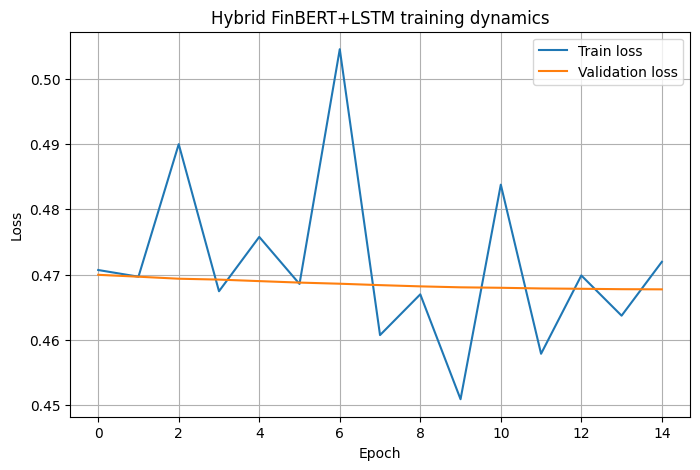

In [12]:
# ================================================================
# Ячейка 11: График потерь гибридной модели
# ================================================================
plt.figure(figsize=(8,5))
plt.plot(train_loss_h, label='Train loss')
plt.plot(val_loss_h, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hybrid FinBERT+LSTM training dynamics')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png', dpi=150)
plt.show()

In [13]:
# ================================================================
# Ячейка 12: Таблица значений функции потерь по эпохам
# ================================================================
loss_df = pd.DataFrame({
    'Epoch': range(1, len(train_loss_h) + 1),
    'Train Loss': train_loss_h,
    'Val Loss': val_loss_h
})
print(loss_df.to_string(index=False))
print("\nМинимальный val loss на эпохе", np.argmin(val_loss_h) + 1, ":", np.min(val_loss_h))
print("Финальный train loss:", train_loss_h[-1])
print("Финальный val loss:", val_loss_h[-1])

 Epoch  Train Loss  Val Loss
     1    0.470699  0.469967
     2    0.469675  0.469675
     3    0.489974  0.469367
     4    0.467447  0.469232
     5    0.475769  0.468999
     6    0.468566  0.468773
     7    0.504516  0.468600
     8    0.460733  0.468385
     9    0.466975  0.468195
    10    0.450911  0.468049
    11    0.483774  0.467978
    12    0.457872  0.467875
    13    0.469864  0.467824
    14    0.463707  0.467762
    15    0.471952  0.467739

Минимальный val loss на эпохе 15 : 0.46773917973041534
Финальный train loss: 0.47195202484726906
Финальный val loss: 0.46773917973041534
